# Bayesian IRT Model — Results Analysis (Output 3)


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    plt.style.use("ggplot")

OUTPUT_DIR = "."
summary = pd.read_csv(f"{OUTPUT_DIR}/nuts_mcmc_summary (3).csv", index_col=0)
vi_draws = pd.read_csv(f"{OUTPUT_DIR}/vi_draws_full (3).csv")
vi_summary = pd.read_csv(f"{OUTPUT_DIR}/vi_summary_comparison (3).csv", index_col=0)
log_lik = pd.read_csv(f"{OUTPUT_DIR}/log_lik_draws (3).csv")
y_rep = pd.read_csv(f"{OUTPUT_DIR}/y_rep_draws (3).csv")
student_df = pd.read_csv(f"{OUTPUT_DIR}/target_student_profiles (3).csv")


## 1. Convergence
R-hat histogram, N_Eff histogram, key parameter table


/Users/kshoker/miniforge3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


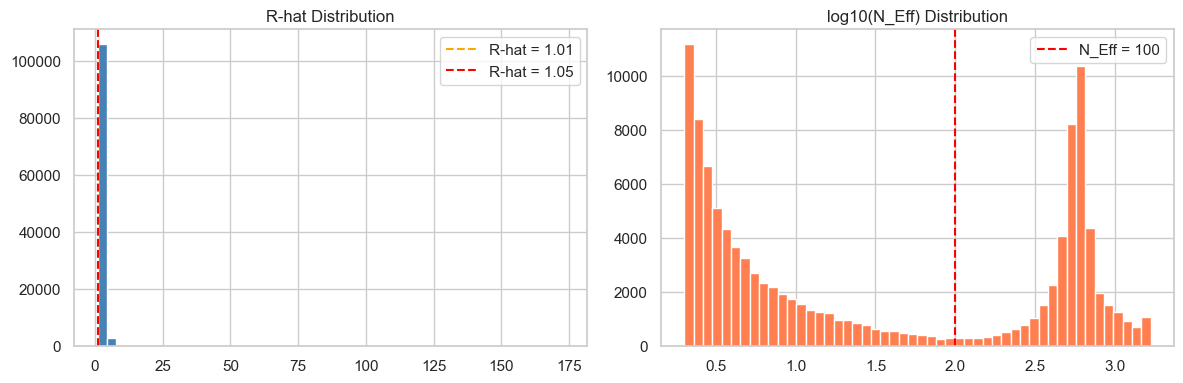

,Mean,StdDev,5%,50%,95%,R_hat,N_Eff
gamma_base,0.23453,0.05830,0.16790,0.29262,0.29264,16.01002,1.01302
gamma_fast_delta,0.04150,0.03523,0.01215,0.01872,0.11817,1.39660,1.76709
alpha,0.77050,0.17194,0.60000,0.85177,0.97917,9.35399,1.01924
mu_log_time,5.32325,0.53622,4.78749,5.84031,5.86727,128.47575,1.01015
sigma_log_time,0.48042,0.48083,0.00000,0.94946,0.96638,173.10228,1.01013
beta_time,0.26184,0.68092,-0.41788,0.84318,0.99881,26.12388,1.01114


In [2]:

rhat = summary['R_hat'].dropna()
neff = summary['N_Eff'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rhat, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(1.01, color='orange', linestyle='--', label='R-hat = 1.01')
axes[0].axvline(1.05, color='red', linestyle='--', label='R-hat = 1.05')
axes[0].set_title('R-hat Distribution')
axes[0].legend()

axes[1].hist(np.log10(neff + 1), bins=50, color='coral', edgecolor='white')
axes[1].axvline(np.log10(100), color='red', linestyle='--', label='N_Eff = 100')
axes[1].set_title('log10(N_Eff) Distribution')
axes[1].legend()
plt.tight_layout()
plt.show()

key_params = ['gamma_base', 'gamma_fast_delta', 'alpha', 'beta_time', 'mu_log_time', 'sigma_log_time']
key_rows = summary.loc[summary.index.intersection(key_params), ['Mean', 'StdDev', '5%', '50%', '95%', 'R_hat', 'N_Eff']]
display(key_rows)


## 2. HMC vs VI Comparison
Side-by-side table + VI density plots with HMC overlaid


,HMC_Mean,HMC_SD,VI_Mean,VI_SD
gamma_base,0.23453,0.05830,0.192885,0.003515
gamma_fast_delta,0.04150,0.03523,NaN,NaN
alpha,0.77050,0.17194,0.728352,0.009114
mu_log_time,5.32325,0.53622,5.832766,0.005591
sigma_log_time,0.48042,0.48083,0.987735,0.003987
beta_time,0.26184,0.68092,0.940369,0.054711


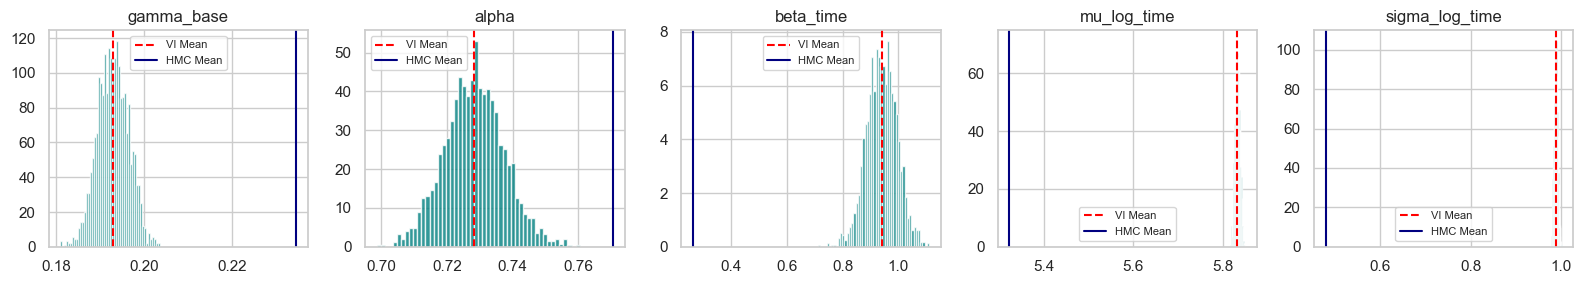

In [3]:

hmc_comp = key_rows[['Mean', 'StdDev']].copy().rename(columns={'Mean': 'HMC_Mean', 'StdDev': 'HMC_SD'})
vi_comp = vi_summary.T[['mean', 'std']].copy().rename(columns={'mean': 'VI_Mean', 'std': 'VI_SD'})
comparison = hmc_comp.join(vi_comp, how='left')
display(comparison)

fig, axes = plt.subplots(1, len(vi_draws.columns), figsize=(16, 3))
for ax, col in zip(axes, vi_draws.columns):
    ax.hist(vi_draws[col], bins=50, color='teal', edgecolor='white', alpha=0.8, density=True)
    ax.axvline(vi_draws[col].mean(), color='red', linestyle='--', label='VI Mean')
    if col in summary.index:
        ax.axvline(summary.loc[col, 'Mean'], color='navy', linestyle='-', label='HMC Mean')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3. Skill Structure
μ_skill & σ_skill across all 69 dimensions with 90% CIs


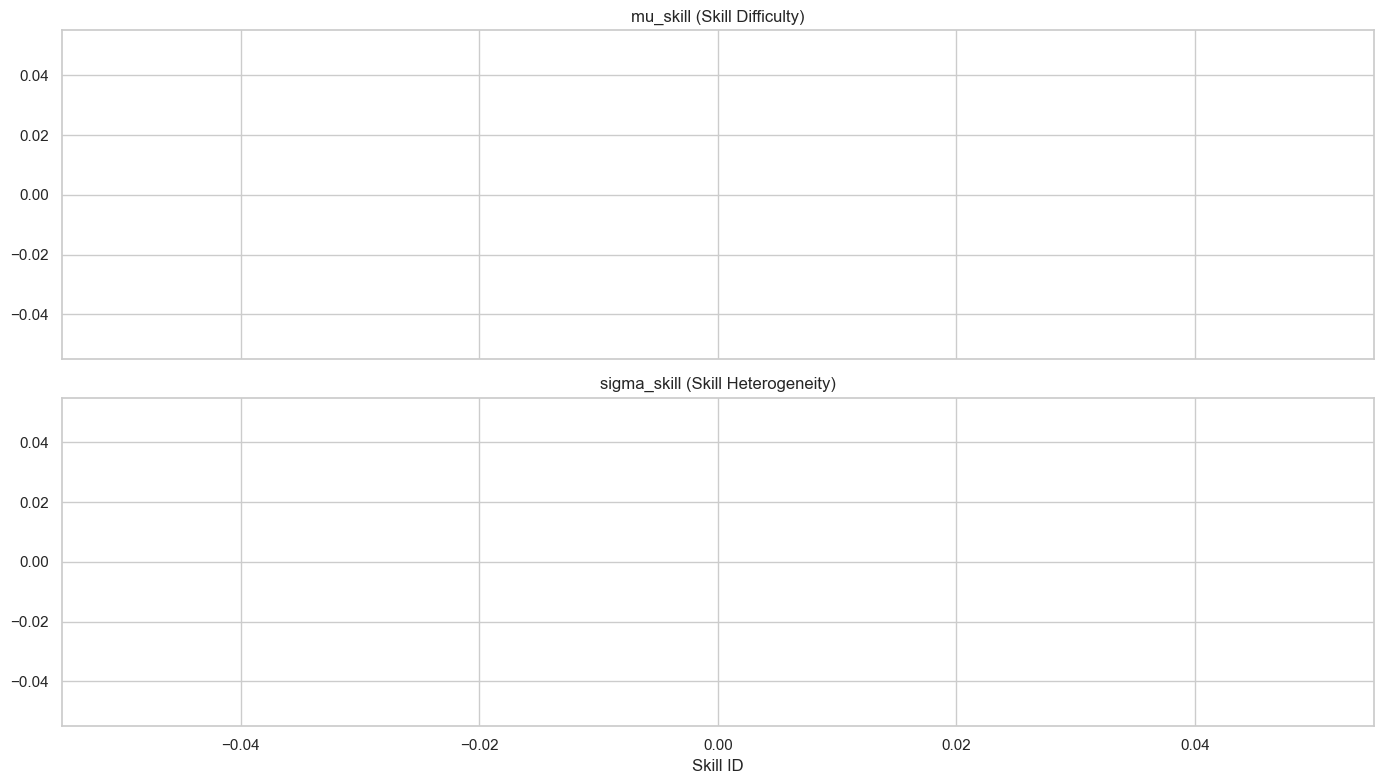

In [4]:

mu_skill = summary[summary.index.str.match(r'^mu_skill\[\d+\]$')].copy()
sigma_skill = summary[summary.index.str.match(r'^sigma_skill\[\d+\]$')].copy()

# Extract skill id
mu_skill['skill'] = mu_skill.index.str.extract(r'\[(\d+)\]')[0].astype(int)
sigma_skill['skill'] = sigma_skill.index.str.extract(r'\[(\d+)\]')[0].astype(int)

mu_skill = mu_skill.sort_values('skill')
sigma_skill = sigma_skill.sort_values('skill')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].errorbar(mu_skill['skill'], mu_skill['Mean'], 
                 yerr=[mu_skill['Mean'] - mu_skill['5%'], mu_skill['95%'] - mu_skill['Mean']], 
                 fmt='o', color='purple', alpha=0.7)
axes[0].set_title('mu_skill (Skill Difficulty)')

axes[1].errorbar(sigma_skill['skill'], sigma_skill['Mean'], 
                 yerr=[sigma_skill['Mean'] - sigma_skill['5%'], sigma_skill['95%'] - sigma_skill['Mean']], 
                 fmt='o', color='green', alpha=0.7)
axes[1].set_title('sigma_skill (Skill Heterogeneity)')
axes[1].set_xlabel('Skill ID')
plt.tight_layout()
plt.show()


## 4. Question Difficulty
Histogram + difficulty vs. uncertainty scatter


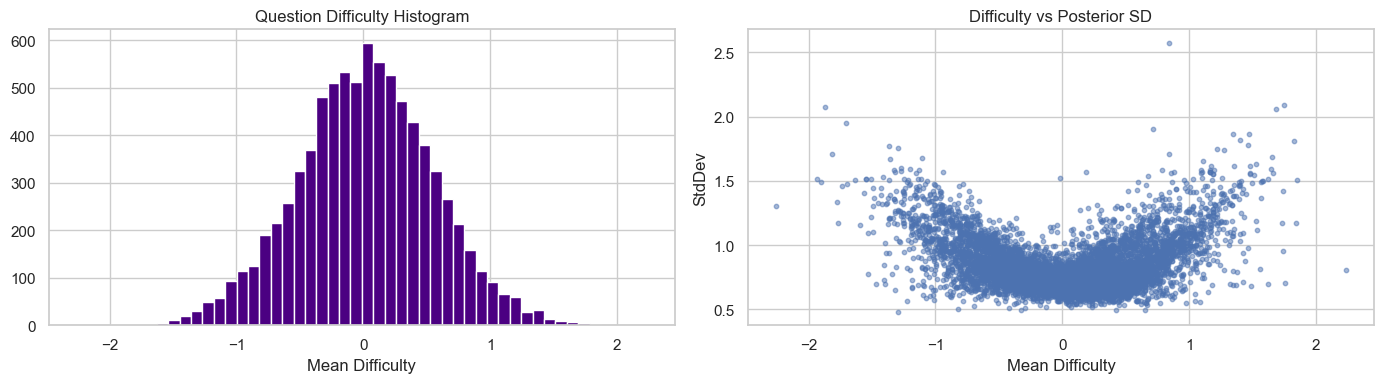

In [5]:

q_diff = summary[summary.index.str.match(r'^question_difficulty\[\d+\]$')].copy()

if len(q_diff) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(q_diff['Mean'], bins=50, color='indigo', edgecolor='white')
    axes[0].set_title('Question Difficulty Histogram')
    axes[0].set_xlabel('Mean Difficulty')
    
    axes[1].scatter(q_diff['Mean'], q_diff['StdDev'], alpha=0.5, s=10)
    axes[1].set_title('Difficulty vs Posterior SD')
    axes[1].set_xlabel('Mean Difficulty')
    axes[1].set_ylabel('StdDev')
    plt.tight_layout()
    plt.show()
else:
    print("No question_difficulty parameters found in summary.")


## 5. Posterior Predictive Check
Per-draw accuracy distribution vs. observed mean


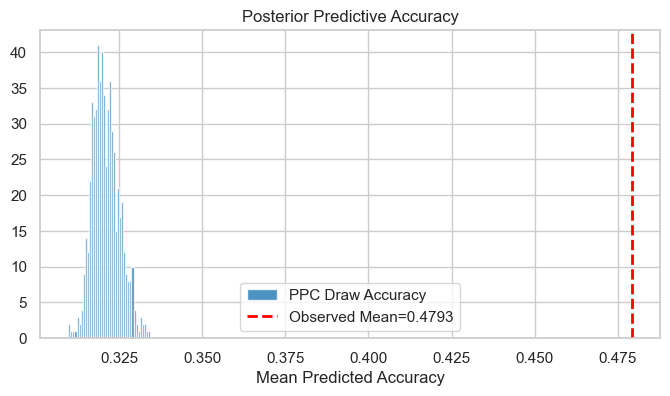

In [6]:

# y_rep columns correspond to observations. Each row is a draw.
draw_acc = y_rep.mean(axis=1)

obs_mean = 0.4793

plt.figure(figsize=(8, 4))
plt.hist(draw_acc, bins=40, color='tab:blue', alpha=0.8, label='PPC Draw Accuracy')
plt.axvline(obs_mean, color='red', linestyle='--', lw=2, label=f'Observed Mean={obs_mean}')
plt.title('Posterior Predictive Accuracy')
plt.xlabel('Mean Predicted Accuracy')
plt.legend()
plt.show()


## 6. Student Profiles
Bar charts per student + pairwise skill scatter


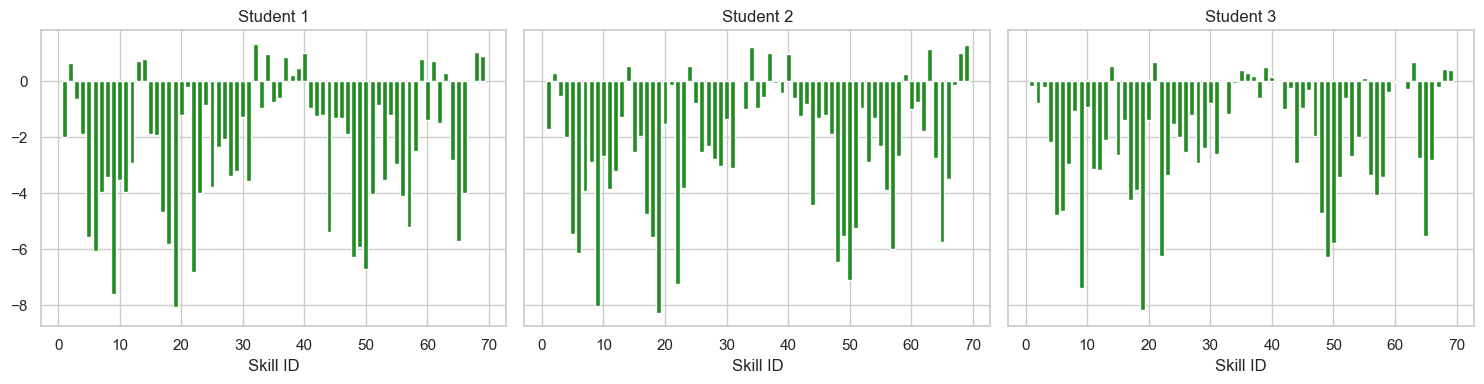

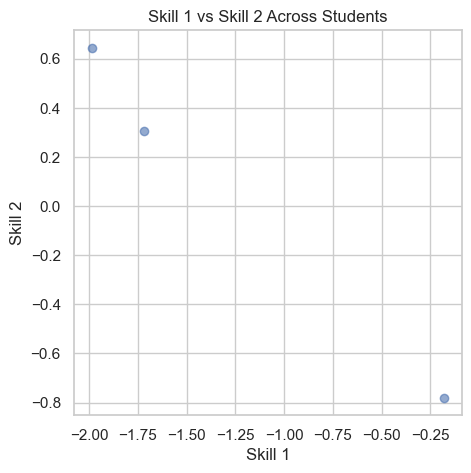

In [7]:

profiles = []
import re
for col in student_df.columns:
    m = re.match(r'^user_skill\[(\d+),(\d+)\]$', col.strip('"'))
    if m:
        student_id, skill_id = int(m.group(1)), int(m.group(2))
        profiles.append({
            'student_id': student_id,
            'skill_id': skill_id,
            'mean_skill': student_df[col].mean()
        })
prof_df = pd.DataFrame(profiles)

if len(prof_df) > 0:
    # Plot top 3 students
    students = prof_df['student_id'].unique()[:3]
    fig, axes = plt.subplots(1, len(students), figsize=(5 * len(students), 4), sharey=True)
    if len(students) == 1: axes = [axes]
    
    for ax, student in zip(axes, students):
        sub = prof_df[prof_df['student_id'] == student]
        ax.bar(sub['skill_id'], sub['mean_skill'], color='forestgreen')
        ax.set_title(f'Student {student}')
        ax.set_xlabel('Skill ID')
    plt.tight_layout()
    plt.show()
    
    # Pairwise skill scatter for first two skills if tracking more than 1
    pivoted = prof_df.pivot(index='student_id', columns='skill_id', values='mean_skill')
    if len(pivoted.columns) >= 2:
        k1, k2 = pivoted.columns[0], pivoted.columns[1]
        plt.figure(figsize=(5, 5))
        plt.scatter(pivoted[k1], pivoted[k2], alpha=0.6)
        plt.title(f'Skill {k1} vs Skill {k2} Across Students')
        plt.xlabel(f'Skill {k1}')
        plt.ylabel(f'Skill {k2}')
        plt.show()
else:
    print("No user_skill distributions found in target_student_profiles.")


## 7. LOO-CV
Per-obs log-lik distribution (+ PSIS-LOO if arviz installed)


arviz not installed. Skipping PSIS-LOO.


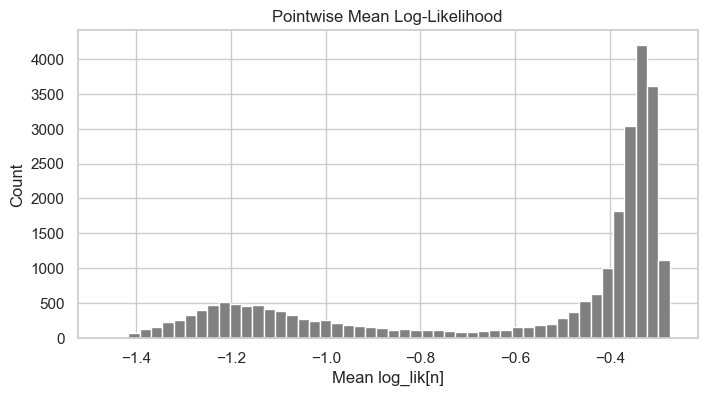

In [8]:

try:
    import arviz as az
    # Arviz requires log_lik in shape (chains, draws, obs) or (draws, obs)
    log_lik_ary = log_lik.to_numpy()
    loo = az.loo(log_lik_ary)
    display(loo)
except ImportError:
    print('arviz not installed. Skipping PSIS-LOO.')

mean_ll = log_lik.mean(axis=0)
plt.figure(figsize=(8, 4))
plt.hist(mean_ll, bins=50, color='gray', edgecolor='white')
plt.title('Pointwise Mean Log-Likelihood')
plt.xlabel('Mean log_lik[n]')
plt.ylabel('Count')
plt.show()


## 8. Report Conclusions
Auto-printed text summary for copy-paste into report


In [9]:

print("="*40)
print("REPORT CONCLUSIONS")
print("="*40)
print(f"- MCMC Parameters    : {len(summary):,}")
print(f"- R-hat Max          : {rhat.max():.4f}")
print(f"- N_Eff Min          : {neff.min():.1f}")
print(f"- PPC Accuracy       : {draw_acc.mean():.4f} (Observed: {obs_mean:.4f})")

if len(q_diff) > 0:
    print(f"- Mean Difficulty    : {q_diff['Mean'].mean():.4f}")

global_params = ['gamma_base', 'alpha', 'beta_time', 'mu_log_time', 'sigma_log_time']
print("\nGlobal Parameters Overview (HMC):")
print(summary.loc[summary.index.intersection(global_params), ['Mean', 'StdDev']])


REPORT CONCLUSIONS
- MCMC Parameters    : 108,818
- R-hat Max          : 173.1023
- N_Eff Min          : -810748.0
- PPC Accuracy       : 0.3209 (Observed: 0.4793)
- Mean Difficulty    : 0.0176

Global Parameters Overview (HMC):
                   Mean   StdDev
gamma_base      0.23453  0.05830
alpha           0.77050  0.17194
mu_log_time     5.32325  0.53622
sigma_log_time  0.48042  0.48083
beta_time       0.26184  0.68092
